In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
import seaborn as sns
sns.set_theme(context='notebook', style='ticks')
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.167:43965 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.167:43965,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


2026-02-17 17:54:29,400 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:9064', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired

In [5]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [6]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 150)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

In [7]:
z_i = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])
ds = ds.assign_coords({"z_i":z_i})

In [8]:
import xshelftransects

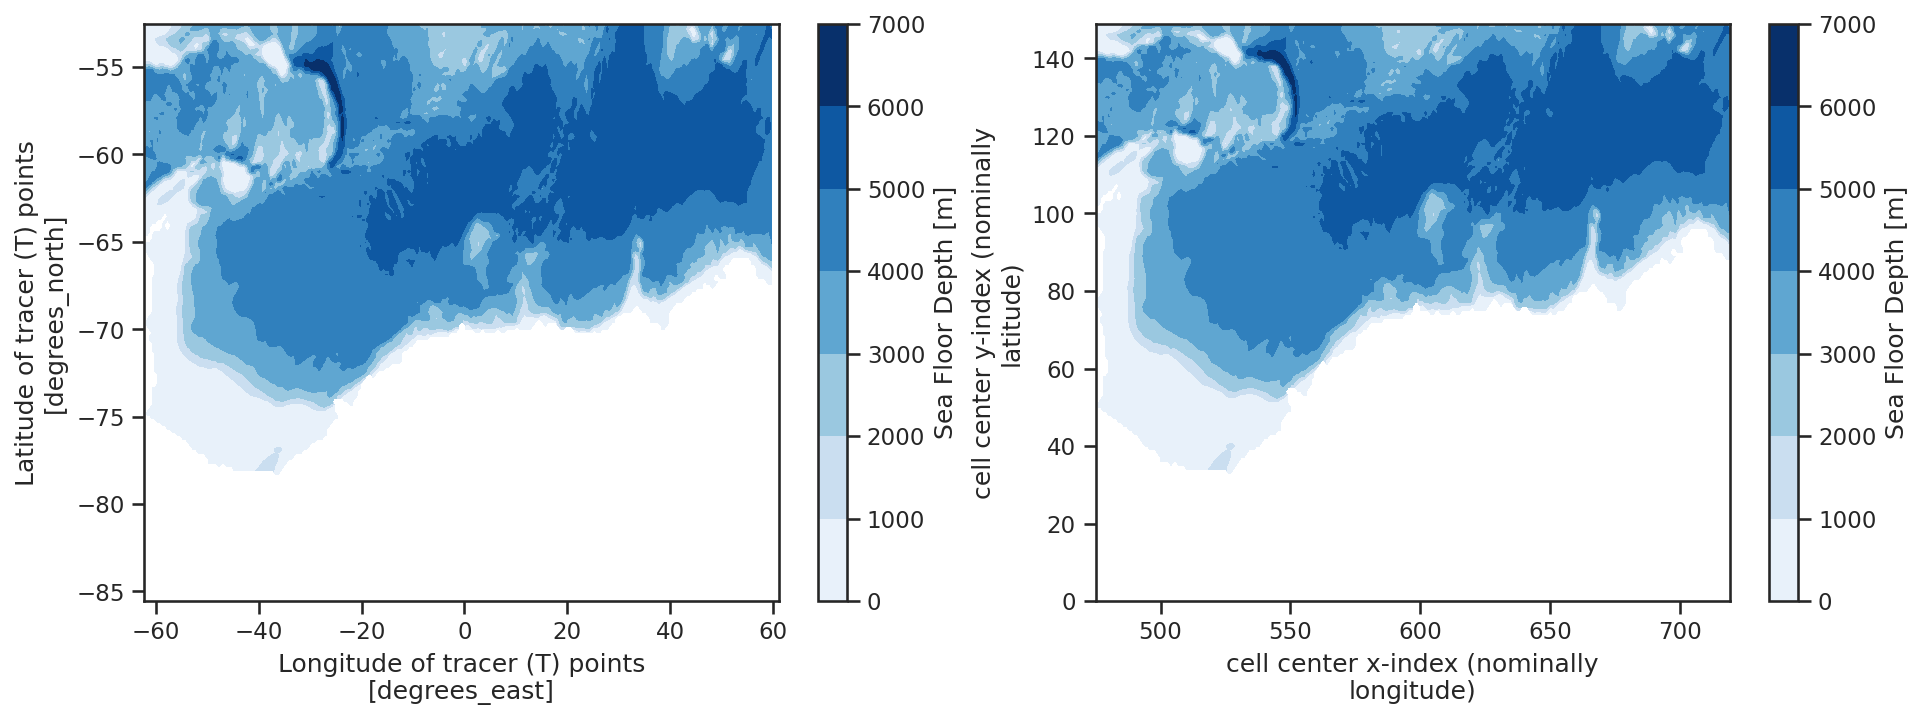

In [9]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, 1000))
ds_subset.deptho.plot.contourf(ax = ax[0], x = "geolon", y = "geolat", cmap = "Blues")
ds_subset.deptho.plot.contourf(ax = ax[1], cmap = "Blues")

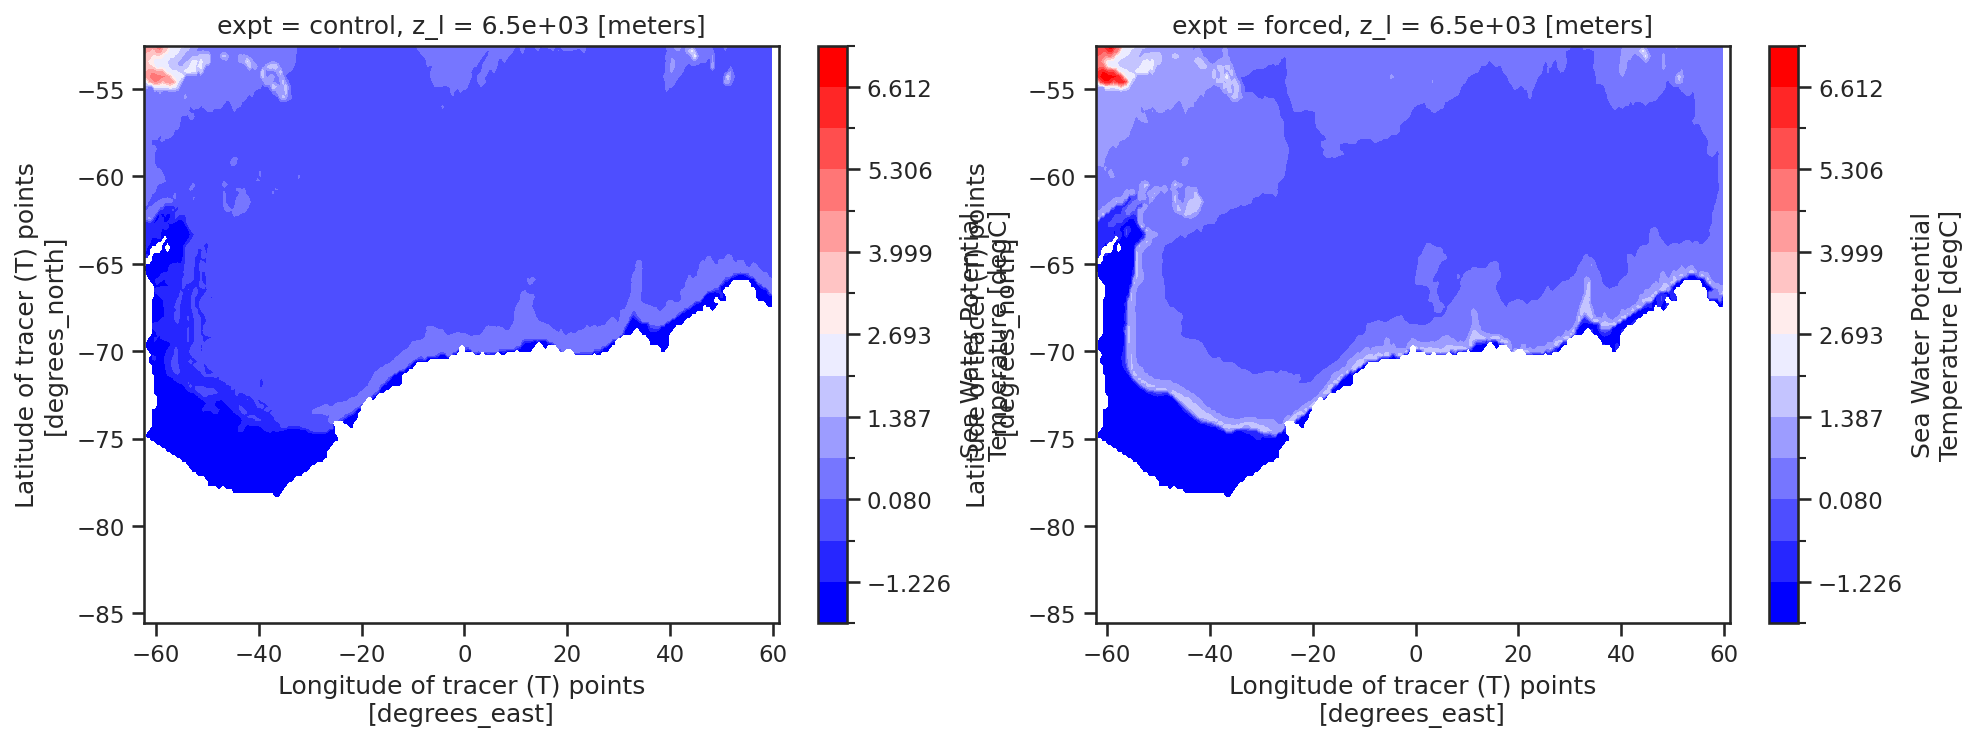

In [10]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-50, None)).mean("year").ffill("z_l")
ds_subset = ds_subset.thetao.isel(z_l = -1)
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 15)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")

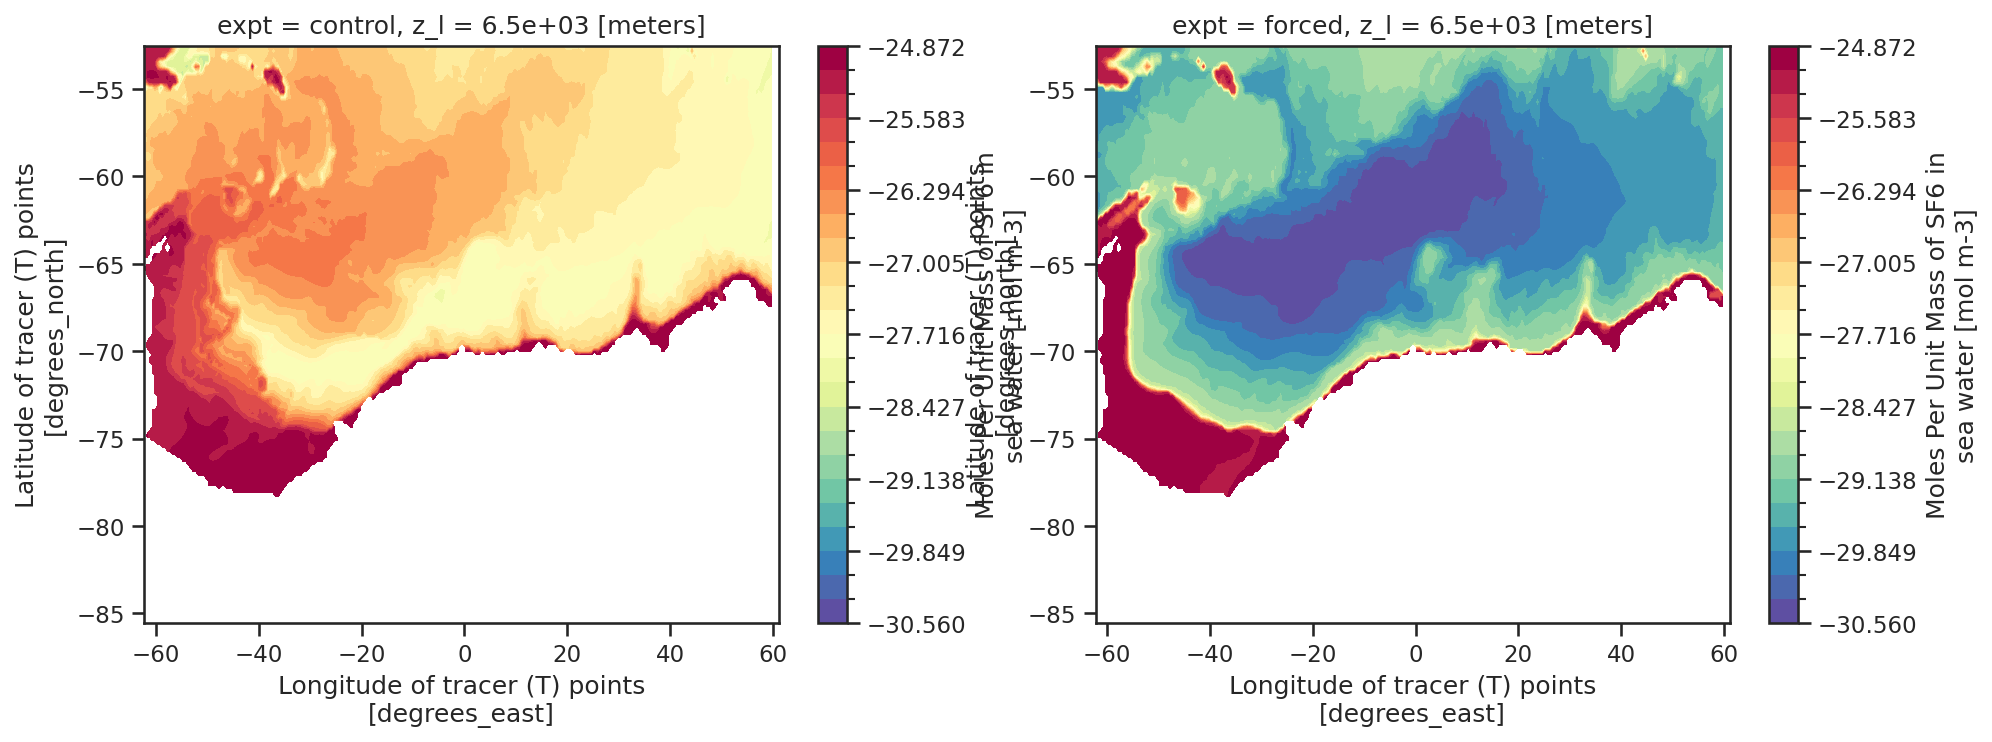

In [11]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-25, None)).mean("year").ffill("z_l")
ds_subset = np.log(ds_subset.sf6.isel(z_l = -1))
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 25)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")

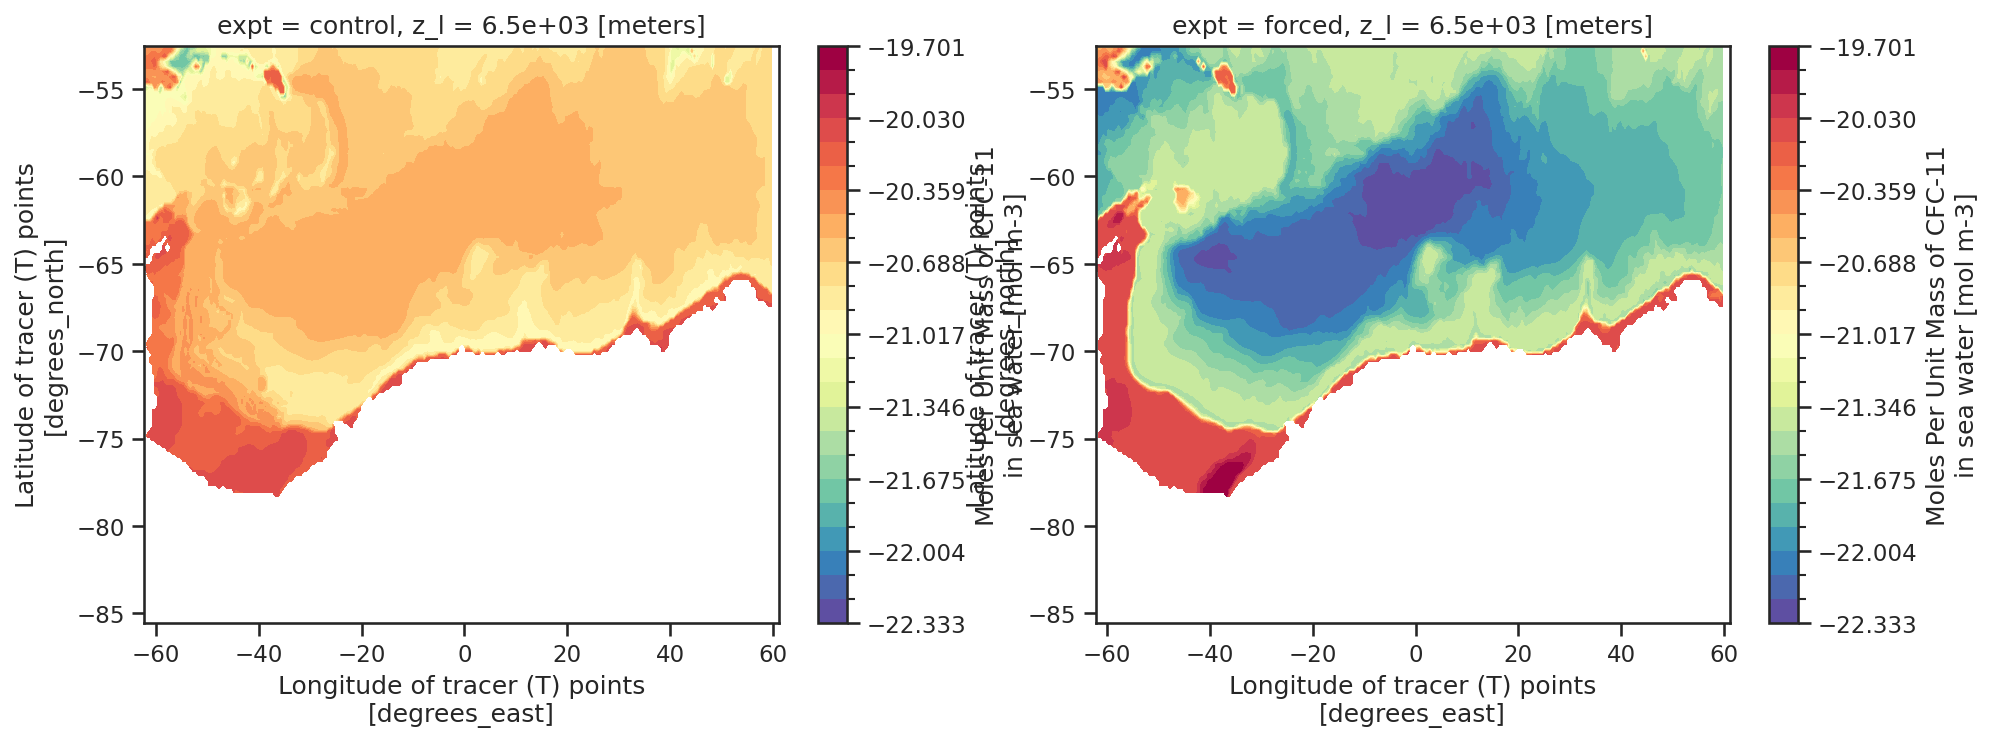

In [12]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-25, None)).mean("year").ffill("z_l")
ds_subset = np.log(ds_subset.cfc11.isel(z_l = -1))
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 25)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")

In [13]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})
ds_weddell = rename_geocoords(ds)
ds_weddell = ds_weddell.reset_coords(names='deptho')
ds_weddell = ds_weddell.isel(xh = slice(475, 600))
ds_weddell_zstar = 1 * ds_weddell

Inferring Z grid coordinate: depth `z_`


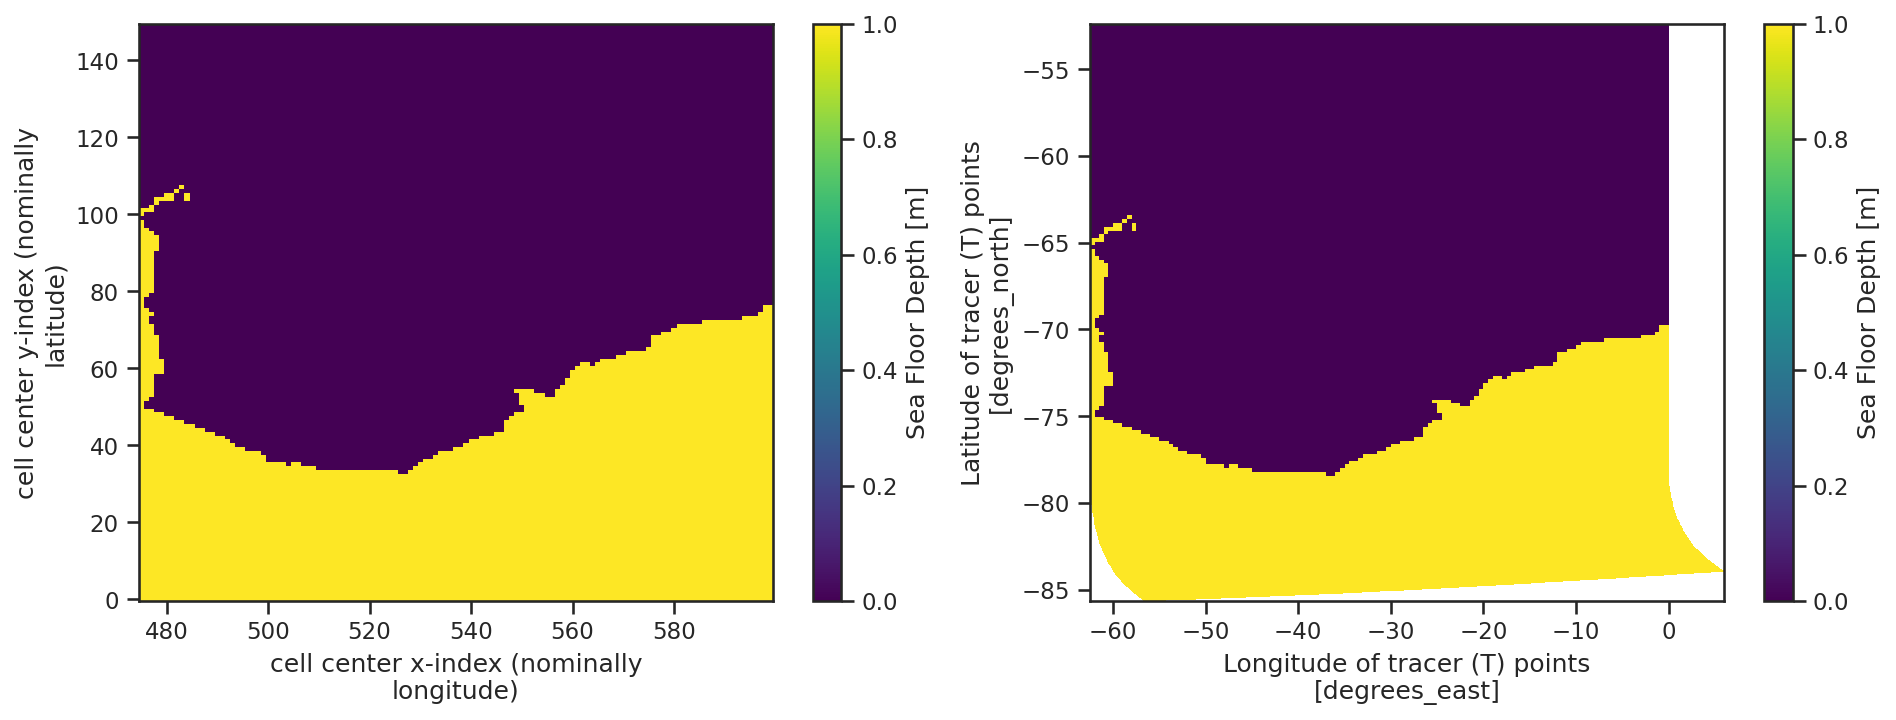

In [14]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})

ds_filtered = ds.where(ds.thkcello.fillna(0.0) > 0.0)
ds_remap = remap_vcoord_to_depth(ds_filtered, vcoord = "z", new_vcoord = "depth")
ds_weddell = rename_geocoords(ds_remap).rename({"depth_l":"z_l"})
ds_weddell = ds_weddell.reset_coords(names='deptho')
ds_weddell = ds_weddell.isel(xh = slice(475, 600))

fig, ax = plt.subplots(1,2, figsize = (15, 5))
boundary_mask = (ds_weddell.deptho.fillna(0.0) <= 0.0).compute()
boundary_mask.plot(ax = ax[0])
boundary_mask.plot(ax = ax[1], x = "lon", y = "lat")

(2000.0, 4794.733837890625)

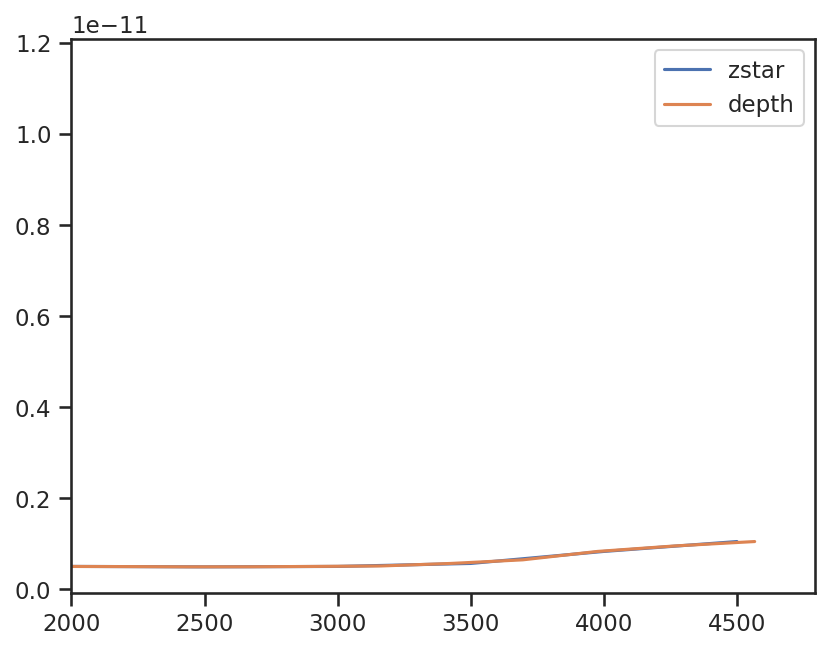

In [15]:
plt.plot(ds_weddell_zstar.z_l, ds_weddell_zstar.sf6.isel(year = -25, expt = 0, xh = 45, yh = 90), label= "zstar")
plt.plot(-ds_weddell.z_l, ds_weddell.sf6.isel(year = -25, expt = 0, xh = 45, yh = 90), label= "depth")
plt.legend()
plt.xlim(2000, None)

(2000.0, 4794.733837890625)

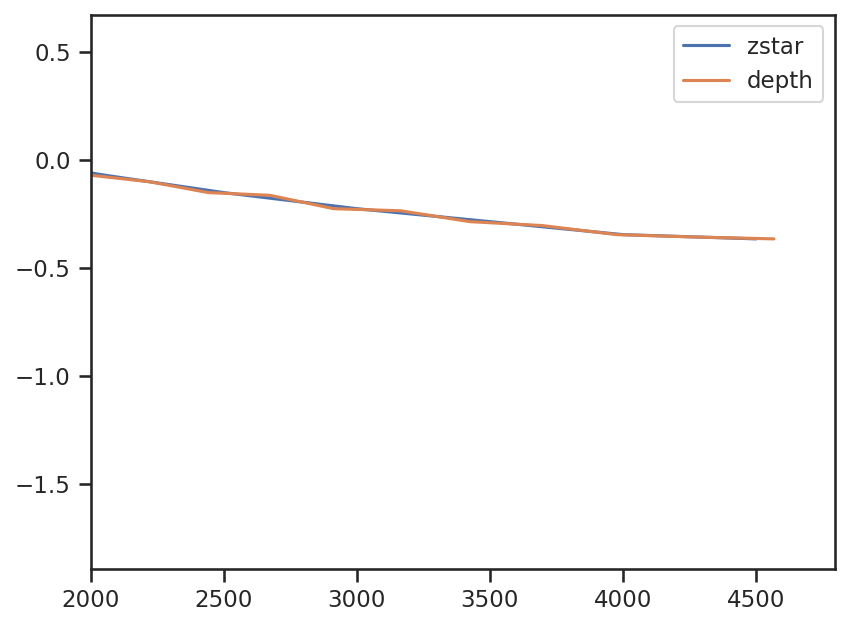

In [16]:
plt.plot(ds_weddell_zstar.z_l, ds_weddell_zstar.thetao.isel(year = -25, expt = 0, xh = 45, yh = 90), label= "zstar")
plt.plot(-ds_weddell.z_l, ds_weddell.thetao.isel(year = -25, expt = 0, xh = 45, yh = 90), label= "depth")
plt.legend()
plt.xlim(2000, None)

In [17]:
transects, geometry = xshelftransects.cross_shelf_transects(
    ds_weddell,
    ["thetao", "cfc11", "sf6", "so", "sigma2_offline"],                    # str | list[str]
    boundary_mask,          # DataArray; contour(level=0.5) defines transect_length=0
    transect_length=np.arange(0.0, 15 * 100e3 + 2e3, 10.0e3),
    transect_spacing=120e3,
    crs="EPSG:3031",
    engine="xesmf",
    method="bilinear",
    lon_name="lon",
    lat_name="lat",
    return_geometry=True,
)


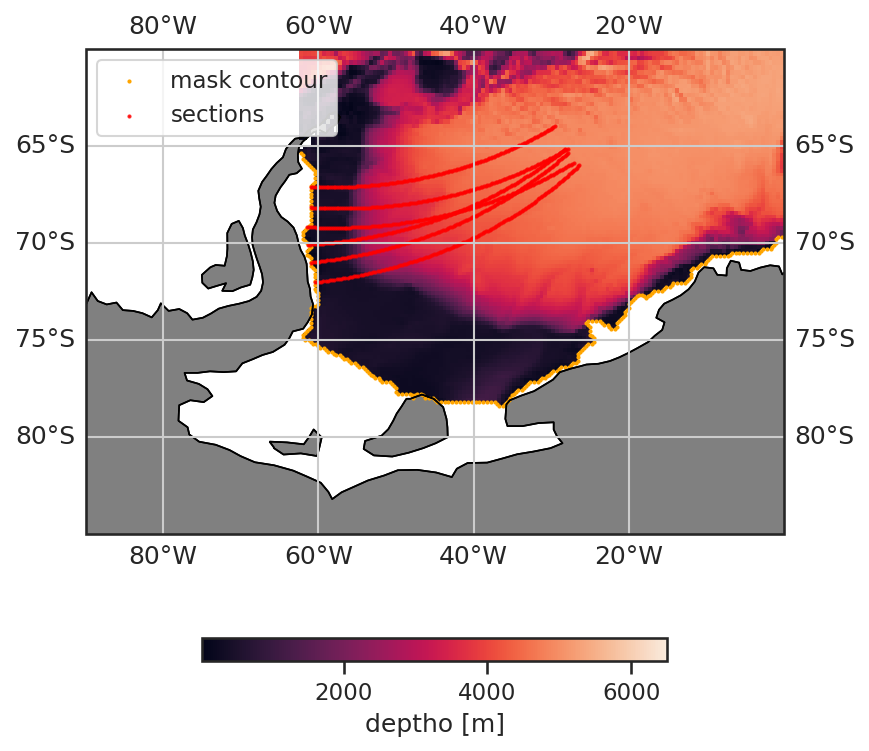

In [18]:
import cartopy.crs as ccrs
import cartopy
# # Plot geometry
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
# ax = plt.axes(projection=ccrs.SouthPolarStereo())
# ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax.set_extent([-90, 0, -85, -60], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m", linewidth=0.8)
ax.coastlines(resolution="110m", linewidth=0.8)
ax.add_feature(cartopy.feature.LAND.with_scale('110m'), facecolor='grey')

gl = ax.gridlines(draw_labels = True);

ax.set_aspect(2.5)
m = ax.pcolormesh(ds_weddell["lon"], ds_weddell["lat"], ds_weddell["deptho"], transform=ccrs.PlateCarree(), shading="auto")
fig.colorbar(m, ax=ax, shrink=0.5, label="deptho [m]", orientation = "horizontal")
ax.scatter(geometry["contour_lon"], geometry["contour_lat"], transform=ccrs.PlateCarree(), s=1, color="orange", 
           label = "mask contour")



# indices = np.concatenate([np.arange(18, 22), np.arange(26, geometry.sizes["section"]-2)])
indices = np.concatenate([np.arange(26, geometry.sizes["section"]-2)])

transects_subset = transects.isel(section = indices) 
for i in range(transects_subset.sizes["section"]): #only taking the ones in the Weddell
    ax.scatter(transects_subset["lon"].isel(section=i), transects_subset["lat"].isel(section=i),
            transform=ccrs.PlateCarree(), s=1, color="red", alpha=0.8, label = "sections")
    if i == 0:
        ax.legend()

In [19]:
avg_transects = transects_subset.mean("section").compute()
time_mean_transects = avg_transects.sel(year = slice(2050, 2100)).mean("year", skipna = True).compute() 

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


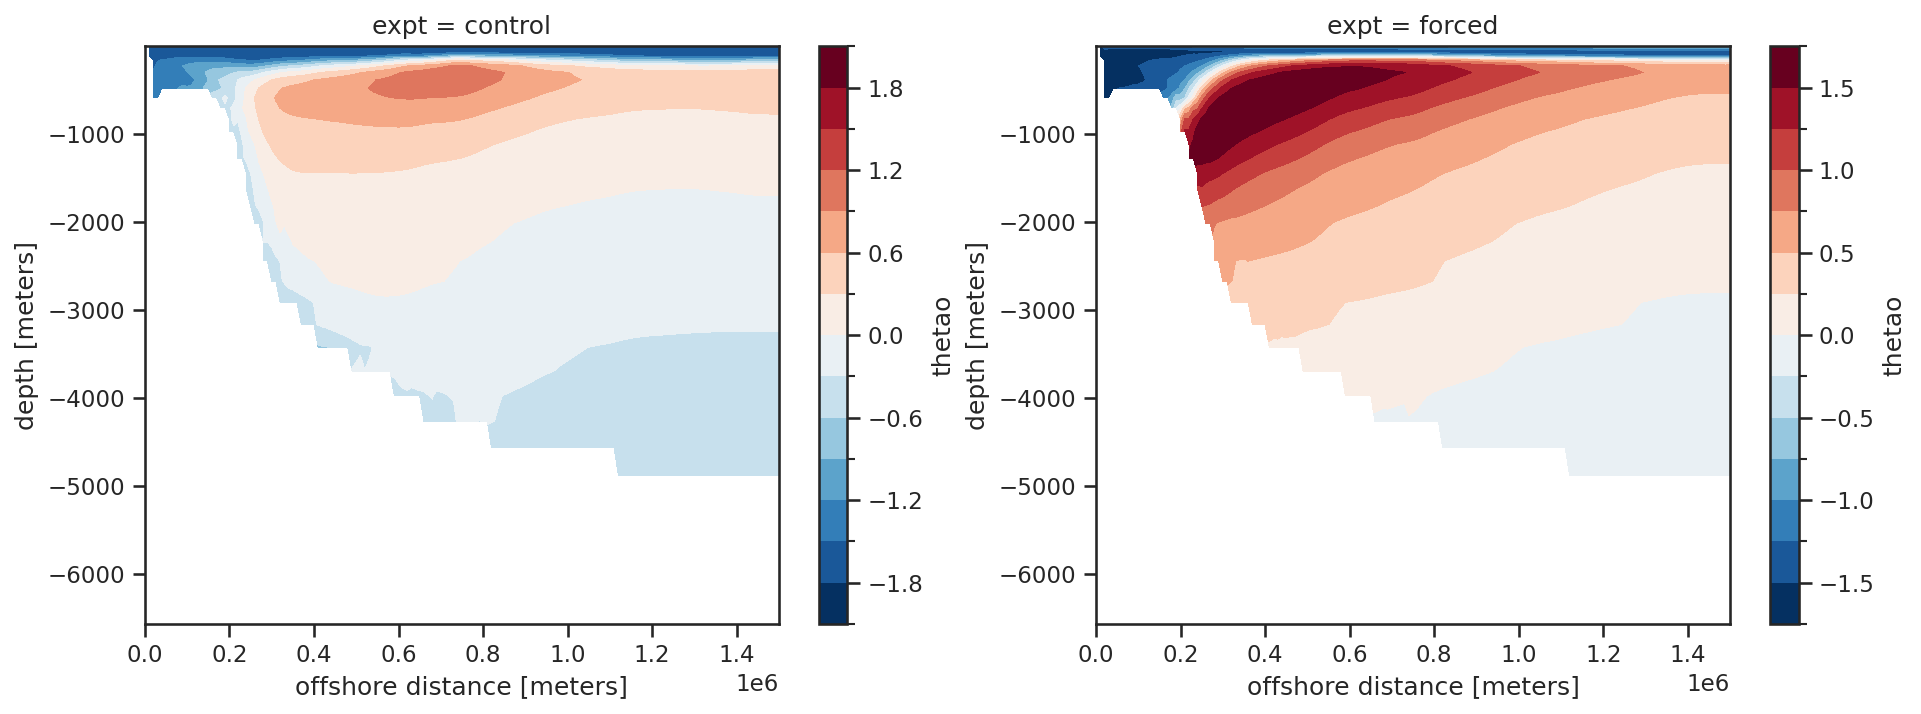

In [20]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = time_mean_transects.thetao
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 15)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 15)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


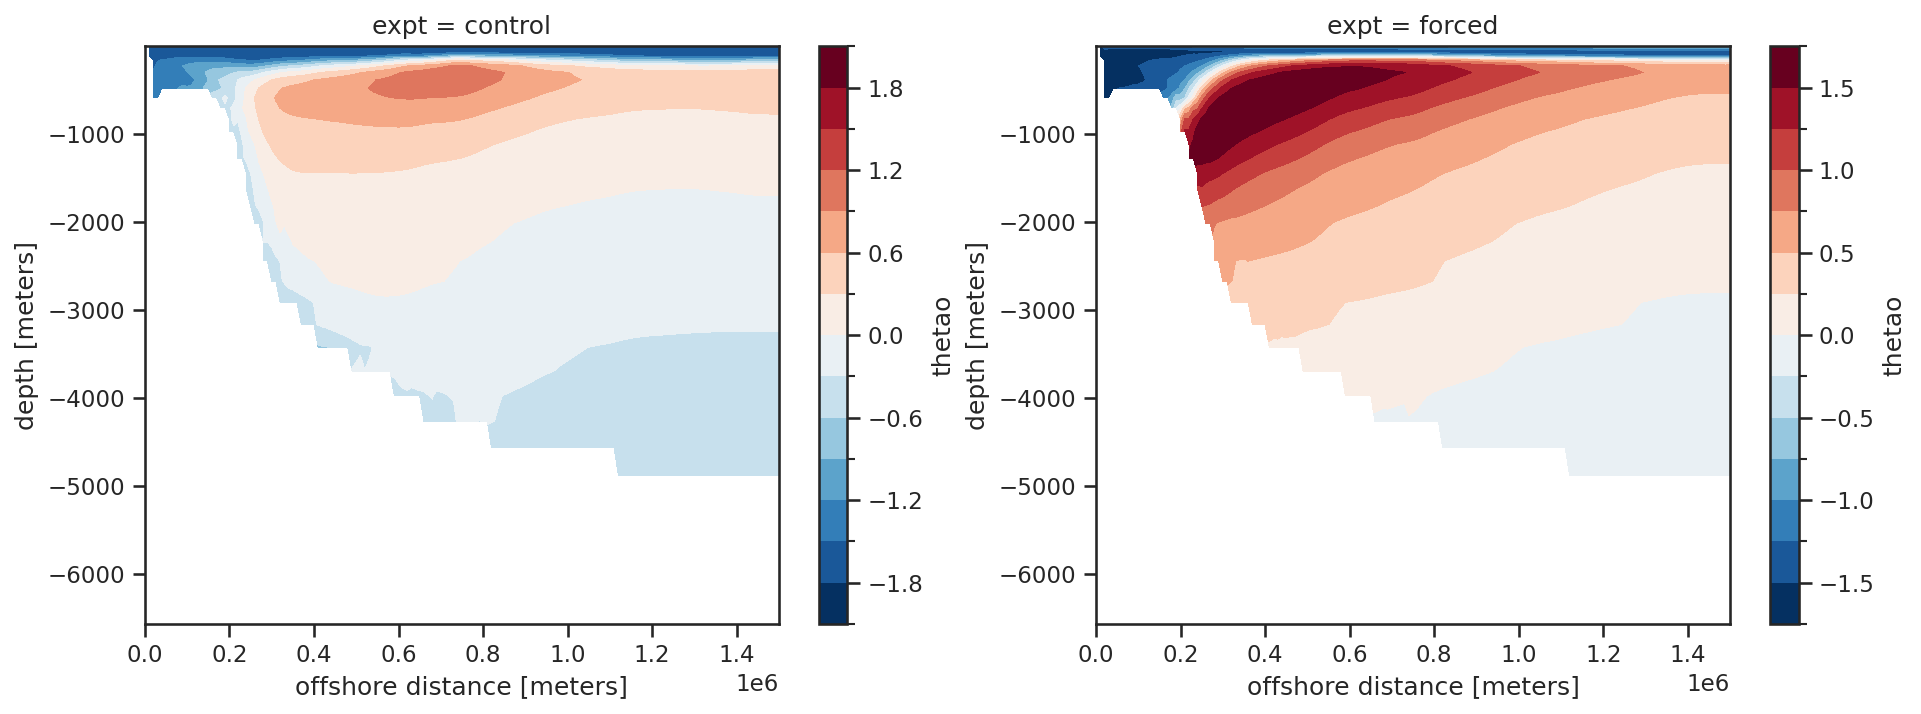

In [21]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = time_mean_transects.thetao
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 15)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 15)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


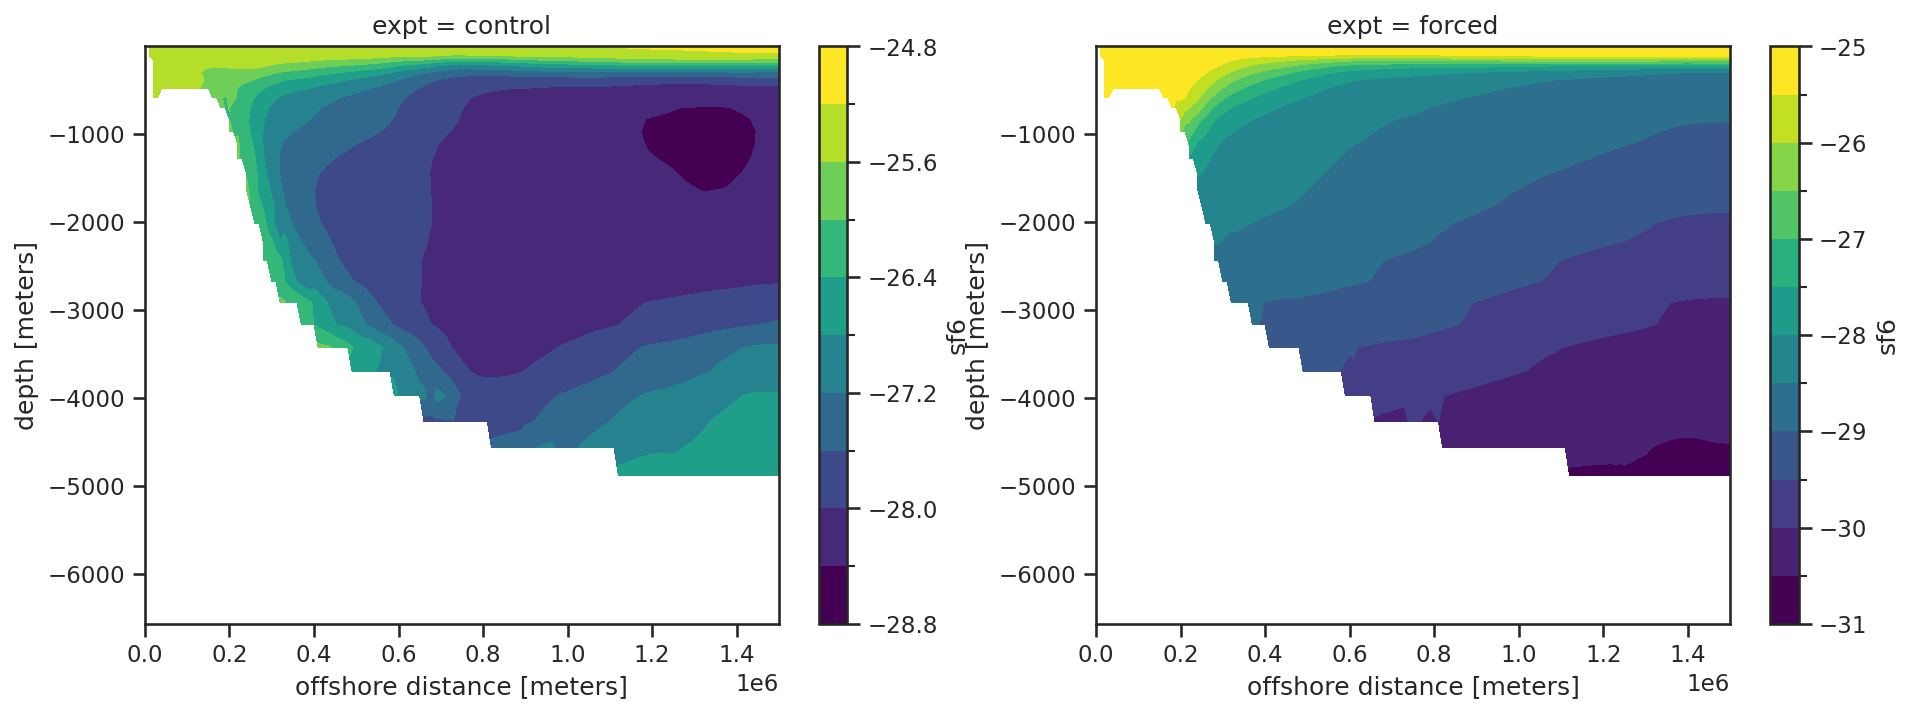

In [22]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.sf6)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")

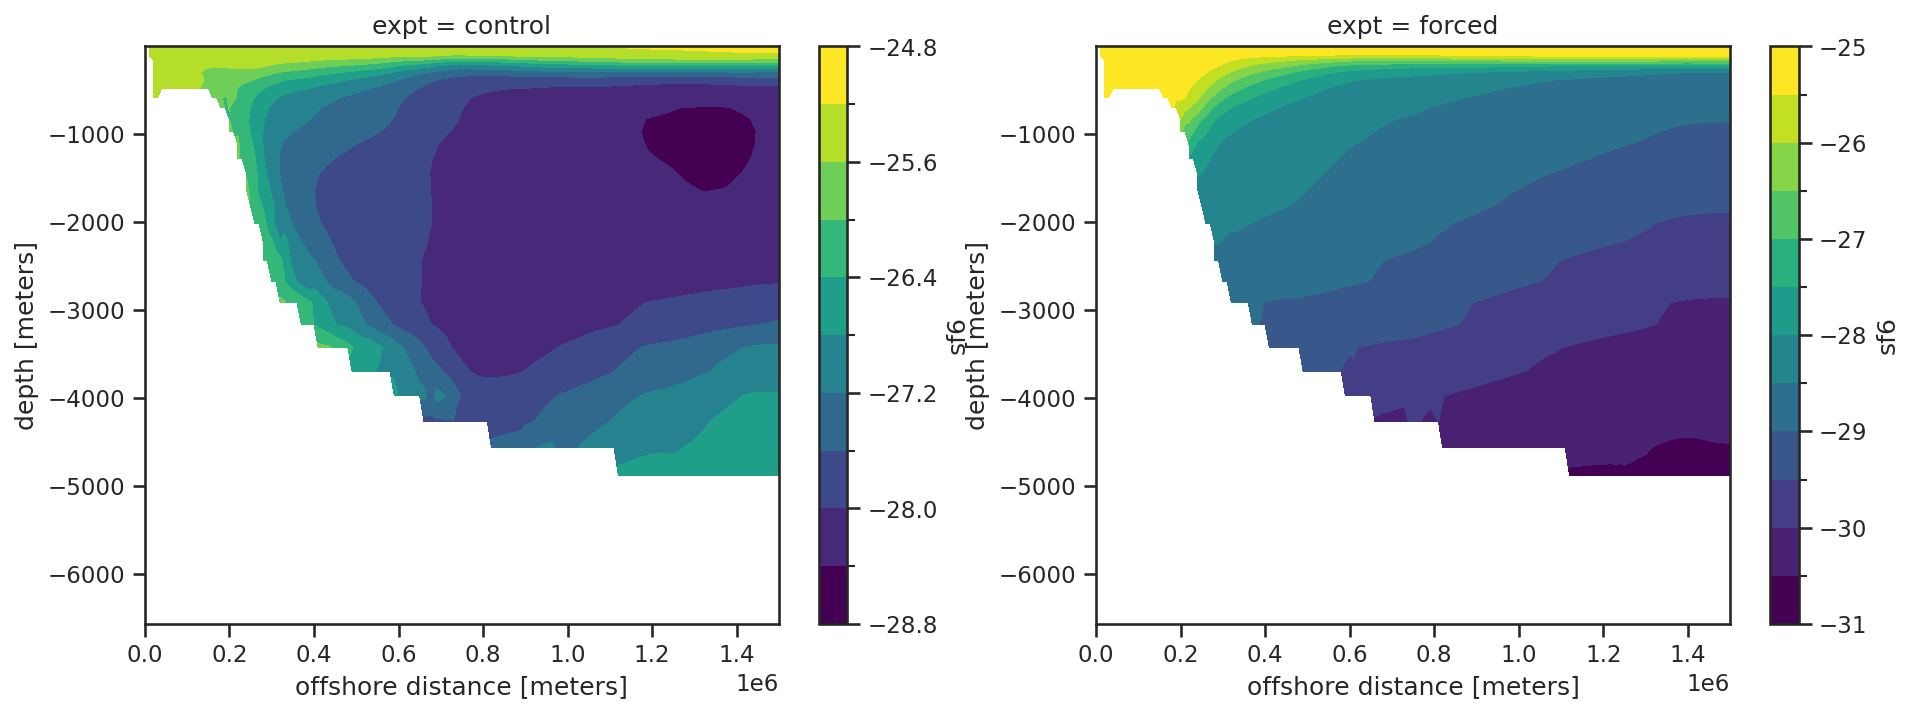

In [23]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.sf6)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")

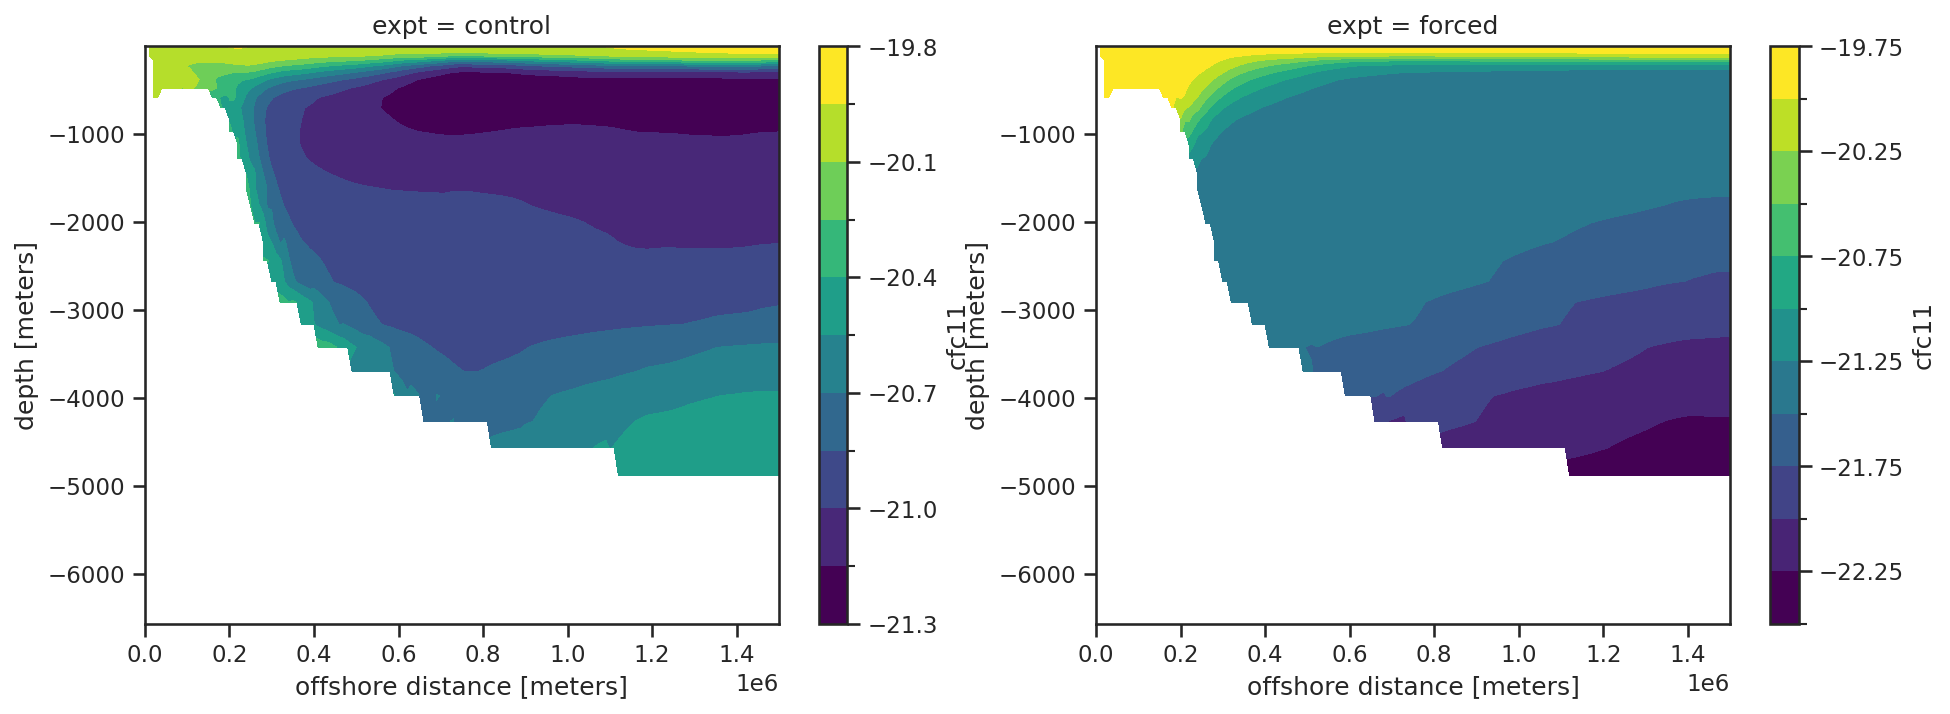

In [24]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.cfc11)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator

import cmocean.cm as cmo
import cmocean
from matplotlib.colors import BoundaryNorm

def weddell_panel(var, mask, z=slice(0, 5000), avg_yrs=slice(2075, None), scale=1.0, 
                  log_scale_contours = False, units="", cbar_units = None, clabel_colors = "k",
                  levels=None, cmap=None, norm = None, surf_loc=(-77.5, 100), bot_loc=(-68.5, 4300),
                  section_title="", top_timeseries_title="", bot_timeseries_title="", plot_contours = False, 
                  transects_subset = None, background_spatial_values = None):
    fig = plt.figure(figsize=(13, 5), constrained_layout=True)
    gs = fig.add_gridspec(4, 3, width_ratios=(0.95, 1.2, 1.0),
    height_ratios=(0.08, 1.0, 1.0, 0.10))
    gs_mid = gs[:, 1].subgridspec(4, 1, hspace=0.01)  # only affects this column

    axA = fig.add_subplot(gs[1:3, 0], projection=ccrs.SouthPolarStereo())
    axB = fig.add_subplot(gs[0:2, 1])
    axC = fig.add_subplot(gs[2:, 1], sharex=axB)
    axD = fig.add_subplot(gs[0:2, 2])
    axE = fig.add_subplot(gs[2:, 2], sharex=axD)
    ax = [axA, axB, axD, axC, axE]

    axA.add_feature(cfeature.LAND, zorder=2)
    axA.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    mA = axA.pcolormesh(background_spatial_values["lon"], background_spatial_values["lat"], background_spatial_values, 
                      transform=ccrs.PlateCarree(), shading="auto", cmap = cmo.deep)
    axA.set_extent([-89, 10, -85, -61], crs=ccrs.PlateCarree())
    for i in range(transects_subset.sizes["section"]): #only taking the ones in the Weddell
        axA.scatter(transects_subset["lon"].isel(section=i), transects_subset["lat"].isel(section=i),
                transform=ccrs.PlateCarree(), s=1, color="red", alpha=0.8, label = "sampled sections")
        if i == 0:
            axA.legend(loc = "upper left")
    # axA.contourf(mask.geolon, mask.geolat, mask.values, levels=[0.5, 1.5], colors="red",
    #              alpha=1.0, transform=ccrs.PlateCarree())
    # after you create axA (your cartopy axis)
    xticks = np.arange(-180, 181, 10)
    yticks = np.arange(-80, -49, 5)

    gl = axA.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, alpha=0.5)
    gl.xlocator = FixedLocator(xticks)
    gl.ylocator = FixedLocator(yticks)
    # gl.top_labels = True
    # gl.right_labels = True
    # gl.bottom_labels = False
    # gl.left_labels = False
    
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 6   # points; increase to push farther outside
    gl.ypadding = 6
    gl.rotate_labels = False
    var = var.sel(z_l=z) * scale
    v = var.sel(year=avg_yrs)
    y0, y1 = int(v.year.min()), int(v.year.max())
    v = v.mean("year")
    if log_scale_contours:
        v = np.log(v)
    if levels is None:
        a = np.asarray(v).ravel(); a = a[np.isfinite(a)]
        levels = np.linspace(a.min(), a.max(), 21) if a.size else 21

    axB.contourf(v.transect_length, v.z_l, v.sel(expt="control"), levels=levels, cmap=cmap, norm = norm, extend = "both")
    cf = axC.contourf(v.transect_length, v.z_l, v.sel(expt="forced"), levels=levels, cmap=cmap, norm = norm, extend = "both")

    if plot_contours: 
        CS = axB.contour(v.transect_length, v.z_l, v.sel(expt="control"), levels=levels, colors=clabel_colors, extend = "both")
        axB.clabel(CS, CS.levels)
        CS = axC.contour(v.transect_length, v.z_l, v.sel(expt="forced"), levels=levels, colors=clabel_colors, extend = "both")
        axC.clabel(CS, CS.levels)

    axB.set_title(section_title)

    axB.text(0.02, 0.02, f"Control ({y0}-{y1})", transform=axB.transAxes, color="w", ha="left", va="bottom", fontsize = 10)
    axC.text(0.02, 0.02, f"Historical/SSP5-8.5 ({y0}-{y1})",  transform=axC.transAxes, color="w", ha="left", va="bottom", fontsize = 10)

    lat_s, z_s = surf_loc
    lat_b, z_b = bot_loc
    for a in (axB, axC):
        a.plot(lat_s, z_s, marker="*", ms=20, mfc="yellow", mec="k", mew=0.8, zorder=10)
        a.plot(lat_b, z_b, marker="o", ms=16,  mfc="yellow", mec="k", mew=0.8, zorder=10)

    axB.set_ylabel("Depth [m]"); axC.set_ylabel("Depth [m]")
    axB.set_xlabel(""); axC.set_xlabel("Offshore Distance [km]")
    axB.tick_params(labelbottom=False)
    axB.set_facecolor("grey"); axC.set_facecolor("grey")

    colors = {"control": "k", "forced": "r"}
    labels = {"control": "Control", "forced": "Historical/SSP5-8.5"}
    ts = var.interp(transect_length=lat_s, z_l=z_s)
    tb = var.interp(transect_length=lat_b, z_l=z_b)
    
    for expt, c in colors.items():
        axD.plot(ts.year, ts.sel(expt=expt), label=labels[expt], c=c)
        axE.plot(tb.year, tb.sel(expt=expt), label=labels[expt], c=c)
    axD.tick_params(labelbottom=False)

    axD.set_title(top_timeseries_title)
    axE.set_title(bot_timeseries_title)
    axD.set_ylabel(f"{units}")
    axE.set_ylabel(f"{units}")
    axD.legend(frameon = False); axE.legend(frameon = False)

    if cbar_units is None: 
        cbar_units = units

    caxA = inset_axes(
    axA,
    width="92%", height="4%",
    loc="lower center",
    bbox_to_anchor=(0.0, -0.2, 1.0, 1.0),   # move up/down with the -0.10
    bbox_transform=axA.transAxes,
    borderpad=0.0,
)
    cbA = fig.colorbar(mA, cax=caxA, orientation="horizontal")
    cbA.set_label("depth [m]")

    fig.colorbar(cf, ax=ax, label=cbar_units, fraction=0.05, extend = "both")
    return fig, ax


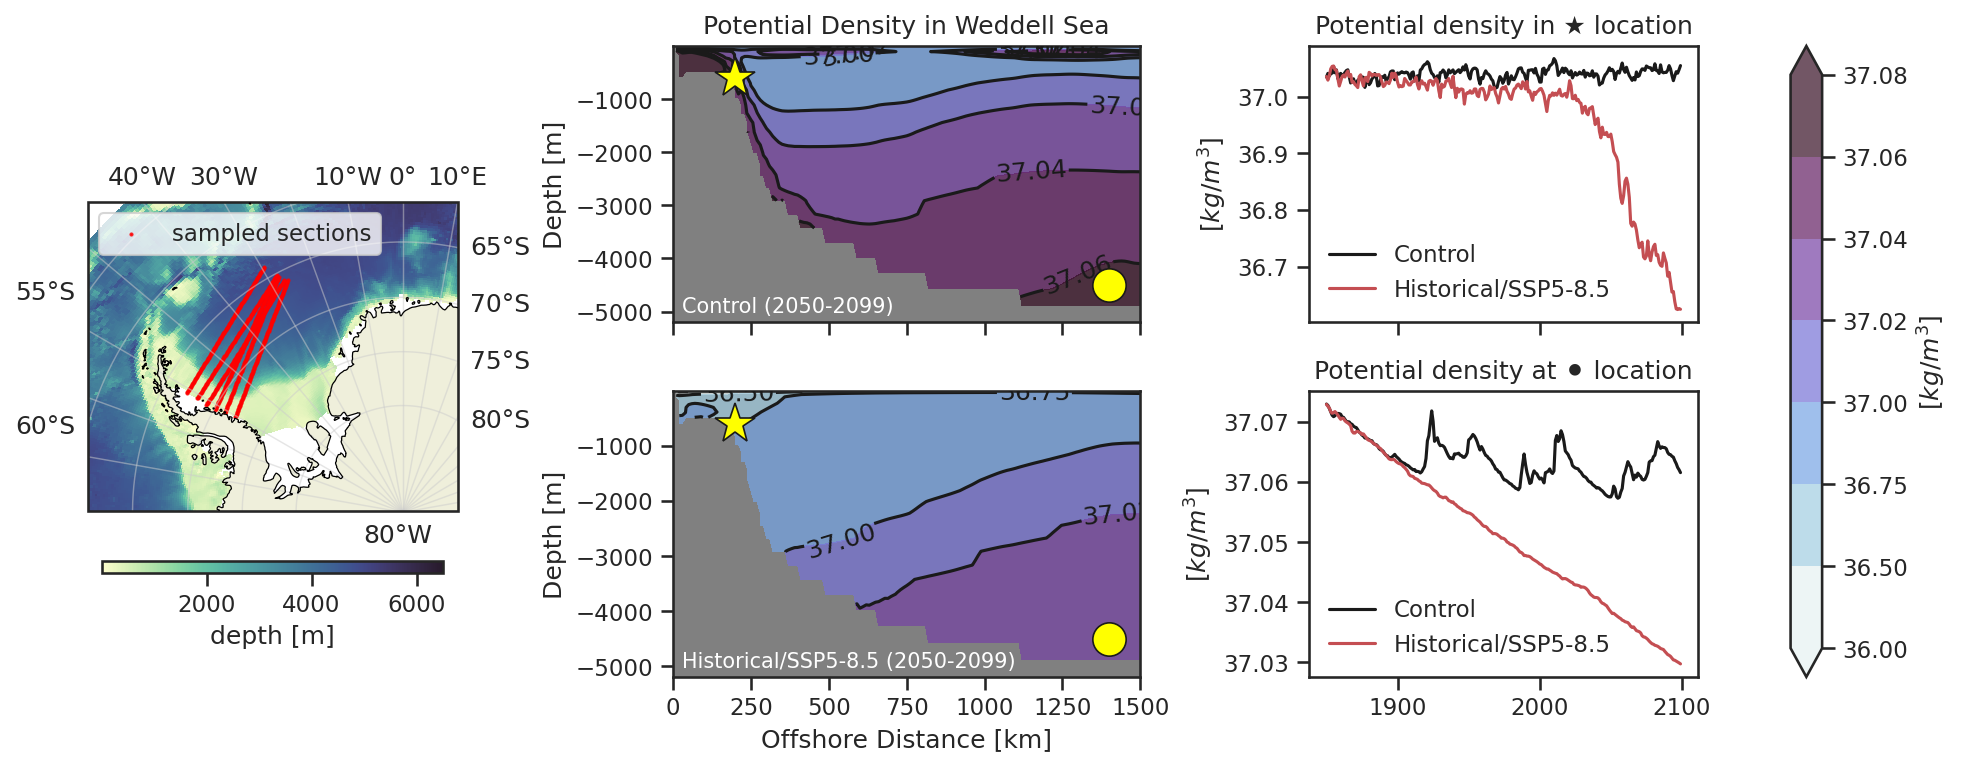

In [56]:
levels = [36.0, 36.5, 36.75, 37.00, 37.02, 37.04, 37.06, 37.08]
cmap = plt.get_cmap(cmocean.tools.lighten(cmo.dense, 0.7), len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

var = 1 * avg_transects.sigma2_offline
var.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

fig, ax = weddell_panel(var, boundary_mask, z=slice(-5500, 0), avg_yrs=slice(2050, None),
                        levels=levels, units=r"$[kg/m^3]$", cmap = cmap, norm = norm, 
                        plot_contours =True, clabel_colors = "k", 
                        surf_loc=(200, -600), bot_loc=(1400, -4500), 
                       section_title =  "Potential Density in Weddell Sea", 
                       top_timeseries_title =  "Potential density in ★ location", 
                       bot_timeseries_title =  "Potential density at ⚫ location", 
                       transects_subset = transects_subset, background_spatial_values=ds["deptho"])

fig.savefig("plots/density_weddell_average.png", dpi = 150, bbox_inches = "tight")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


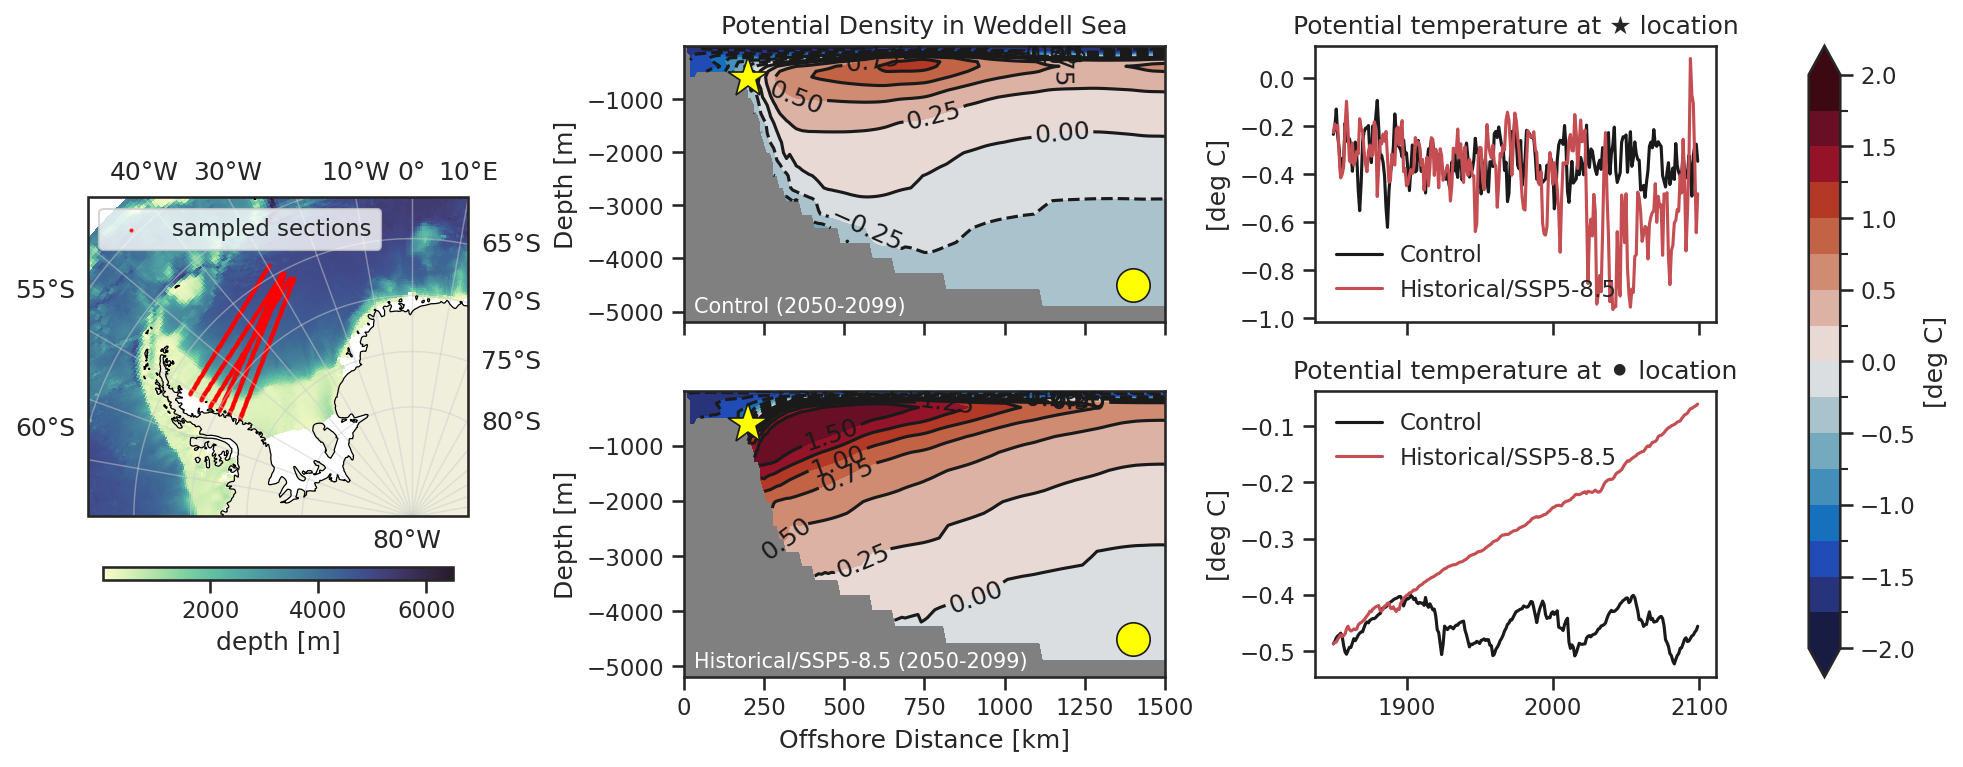

In [57]:
levels = np.arange(-2, 2 + 0.01, 0.25)
cmap = plt.get_cmap(cmo.balance, len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

var = avg_transects.thetao
var.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

fig, ax = weddell_panel(var, boundary_mask, z=slice(-5500, 0), avg_yrs=slice(2050, None),
                        levels=levels, units="[deg C]", cmap = cmap, norm = norm, 
                        plot_contours =True, clabel_colors = "k", 
                        surf_loc=(200, -600), bot_loc=(1400, -4500), 
                       section_title =  "Potential Density in Weddell Sea", 
                       top_timeseries_title =  "Potential temperature at ★ location", 
                       bot_timeseries_title =  "Potential temperature at ⚫ location", 
                       transects_subset = transects_subset, background_spatial_values=ds["deptho"])

fig.savefig("plots/temperature_weddell_average.png", dpi = 150, bbox_inches = "tight")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


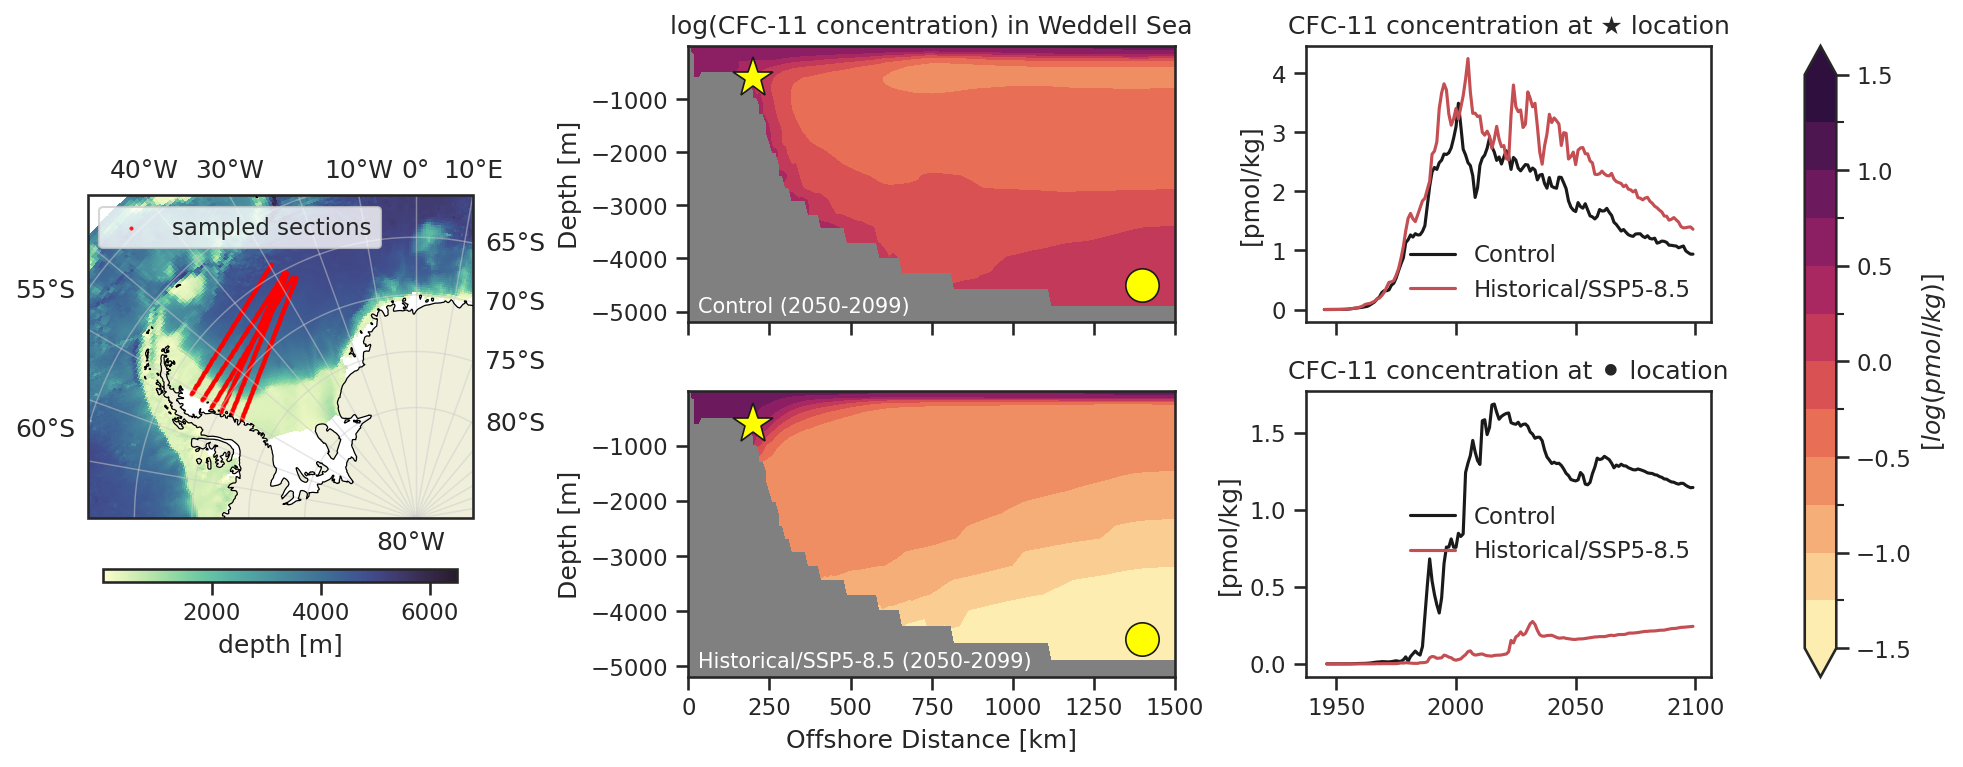

In [58]:
levels = np.arange(-1.5, 1.5 + 0.01, 0.25)
cmap = plt.get_cmap(cmo.matter, len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

var = avg_transects.cfc11 * (1e12/1035)
var.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

fig, ax = weddell_panel(var, boundary_mask, z=slice(-5500, 0), avg_yrs=slice(2050, None),
                        levels=levels, units="[pmol/kg]", cbar_units = r"$[log(pmol/kg)]$",
                        cmap = cmap, norm = norm, 
                        log_scale_contours = True, 
                        surf_loc=(200, -600), bot_loc=(1400, -4500), 
                        plot_contours =False,
                       section_title =  "log(CFC-11 concentration) in Weddell Sea", 
                       top_timeseries_title =  "CFC-11 concentration at ★ location", 
                       bot_timeseries_title =  "CFC-11 concentration at ⚫ location", 
                       transects_subset = transects_subset, background_spatial_values=ds["deptho"])
fig.savefig("plots/cfc11_weddell_average.png", dpi = 150, bbox_inches = "tight")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


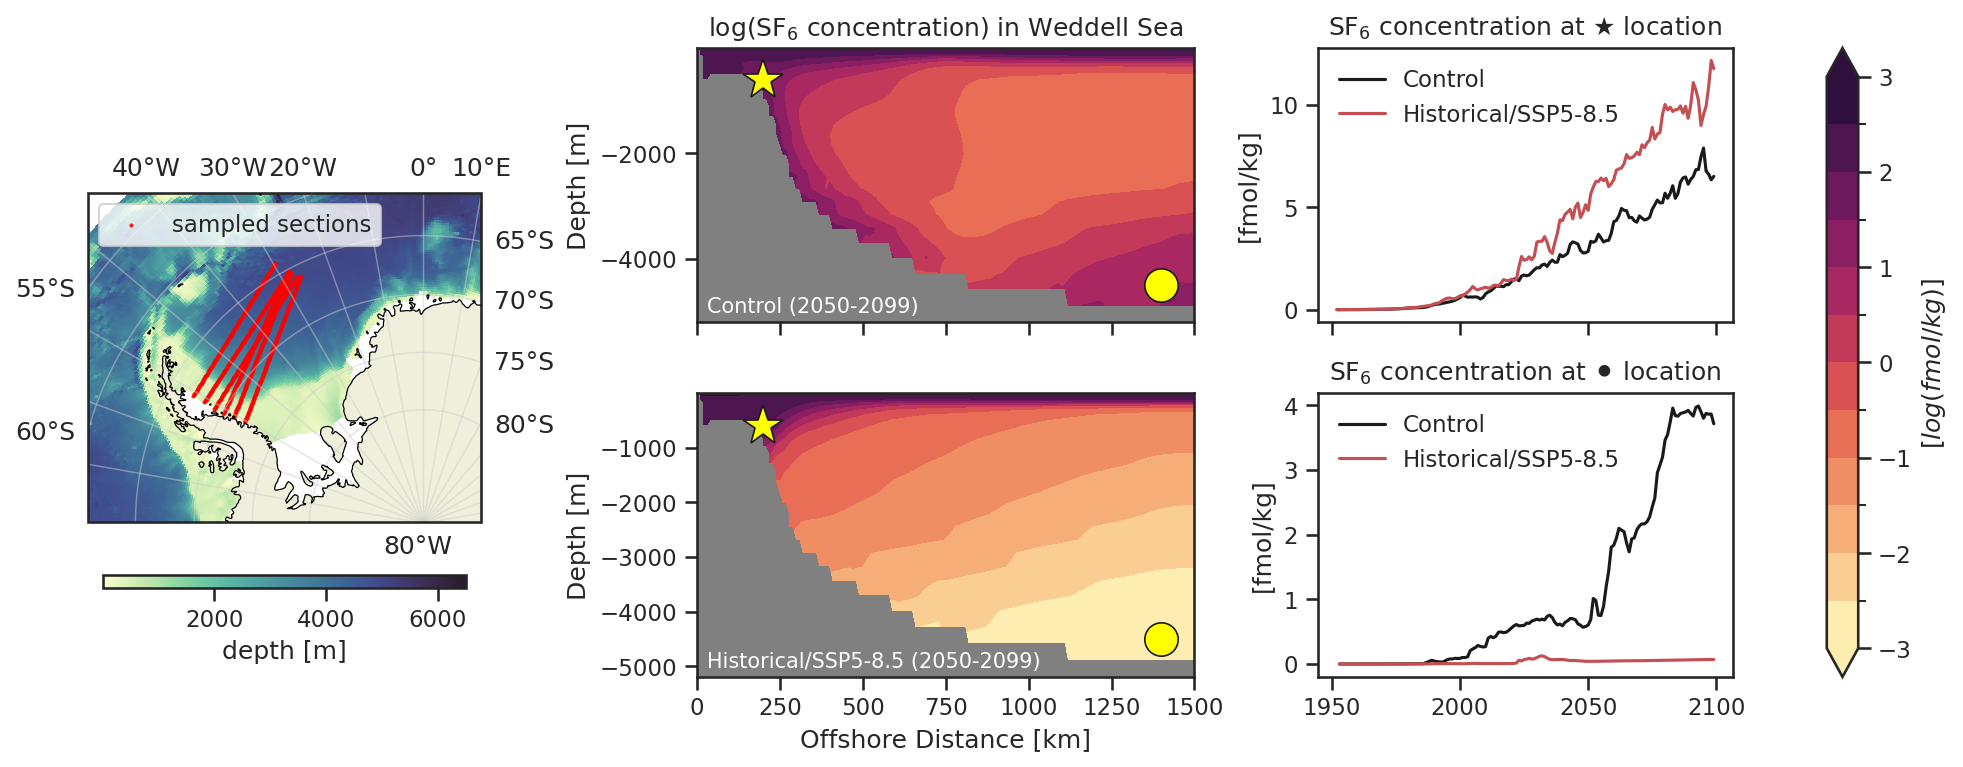

In [59]:
levels = np.arange(-3, 3 + 0.01, 0.5)
cmap = plt.get_cmap(cmo.matter, len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

var = avg_transects.sf6 * 1e12/1035 *1e3
var.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

fig, ax = weddell_panel(var, boundary_mask, z=slice(-5500, 0), avg_yrs=slice(2050, None),
                        levels=levels, units="[fmol/kg]", cbar_units = r"$[log(fmol/kg)]$",
                        cmap = cmap, norm = norm, 
                        log_scale_contours = True, 
                        surf_loc=(200, -600), bot_loc=(1400, -4500), 
                        plot_contours =False,
                       section_title =  r"log(SF$_6$ concentration) in Weddell Sea", 
                       top_timeseries_title =  r"SF$_6$ concentration at ★ location", 
                       bot_timeseries_title =  r"SF$_6$ concentration at ⚫ location", 
                       transects_subset = transects_subset, background_spatial_values=ds["deptho"])
fig.savefig("plots/sf6_weddell_average.png", dpi = 150, bbox_inches = "tight")

Text(0.5, 1.0, 'SF$_6$ spatial variance below 4500 meters')

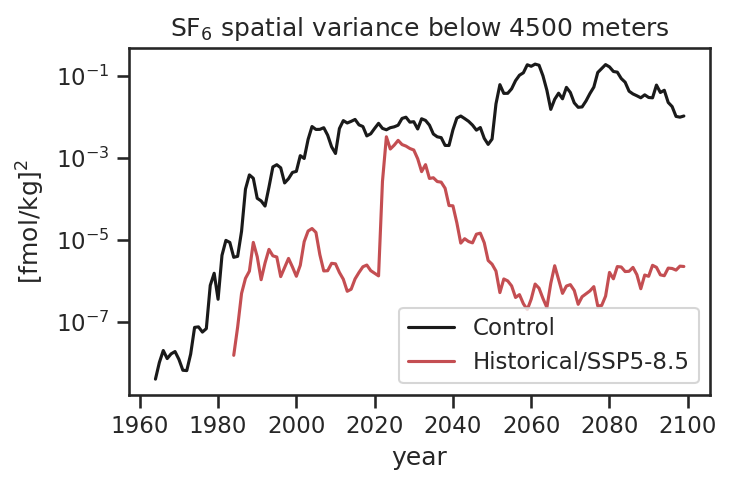

In [60]:
depth_cutoff = 4500

vars_at_deep = 1 * avg_transects
vars_at_deep.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

vars_at_deep = 1 * vars_at_deep.sel(z_l = slice(None, -depth_cutoff), transect_length = slice(1200, None))
vars_at_deep = vars_at_deep.interp(z_l = np.arange(avg_transects.z_l.min().values, avg_transects.z_l.max().values, 10))

vars_at_deep["sf6"] = vars_at_deep["sf6"]  * 1e12/1035 *1e3
vars_at_deep["sf6"] = vars_at_deep["sf6"].where(vars_at_deep["sf6"] > 0.001)
vars_at_deep["cfc11"] = vars_at_deep["cfc11"]  * 1e12/1035
vars_at_deep["cfc11"] = vars_at_deep["cfc11"].where(vars_at_deep["cfc11"] > 0.001)

vars_at_deep = vars_at_deep.var(["z_l", "transect_length"])
vars_at_deep = vars_at_deep.sel(year = slice(None, None))

fig, ax = plt.subplots(figsize = (5, 3))

labels = {"control": "Control", "forced": "Historical/SSP5-8.5"}
colors = {"control": "k", "forced": "r"}
for expt in vars_at_deep.expt.values:
    vars_at_deep.sf6.sel(expt = expt).plot(ax = ax, label = labels[expt], c = colors[expt])

ax.legend()
ax.semilogy()
ax.set_ylabel(r"[fmol/kg$]^2$")
ax.set_title(r"SF$_6$" + f" spatial variance below {depth_cutoff} meters")

FileNotFoundError: [Errno 2] No such file or directory: 'poster_plots/sf6_spatial_variance_below_4500.png'

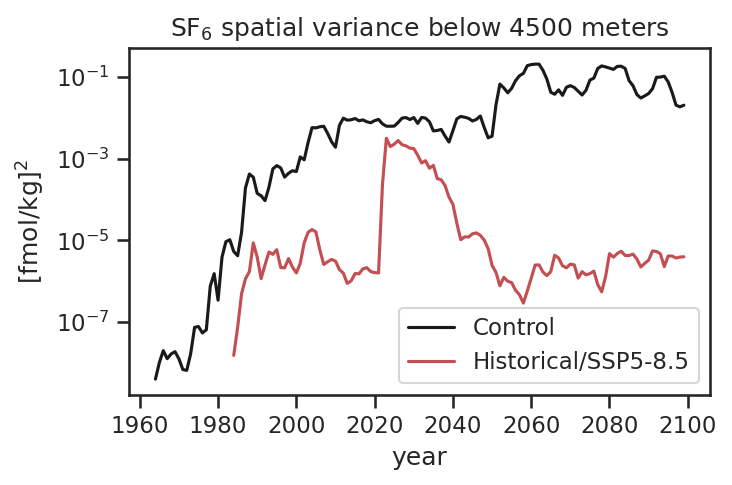

In [61]:
depth_cutoff = 4500
vars_at_deep = 1 * avg_transects.sel(z_l = slice(None, -depth_cutoff), transect_length = slice(None, None))
vars_at_deep = vars_at_deep.interp(z_l = np.arange(avg_transects.z_l.min().values, avg_transects.z_l.max().values, 10))

vars_at_deep["sf6"] = vars_at_deep["sf6"]  * 1e12/1035 *1e3
vars_at_deep["sf6"] = vars_at_deep["sf6"].where(vars_at_deep["sf6"] > 0.001)
vars_at_deep["cfc11"] = vars_at_deep["cfc11"]  * 1e12/1035
vars_at_deep["cfc11"] = vars_at_deep["cfc11"].where(vars_at_deep["cfc11"] > 0.001)

vars_at_deep = vars_at_deep.var(["z_l", "transect_length"])
vars_at_deep = vars_at_deep.sel(year = slice(None, None))

fig, ax = plt.subplots(figsize = (5, 3))

labels = {"control": "Control", "forced": "Historical/SSP5-8.5"}
colors = {"control": "k", "forced": "r"}
for expt in vars_at_deep.expt.values:
    vars_at_deep.sf6.sel(expt = expt).plot(ax = ax, label = labels[expt], c = colors[expt])

ax.legend()
ax.semilogy()
ax.set_ylabel(r"[fmol/kg$]^2$")
ax.set_title(r"SF$_6$" + f" spatial variance below {depth_cutoff} meters")
fig.savefig(f"poster_plots/sf6_spatial_variance_below_{depth_cutoff}.png", dpi = 150, bbox_inches = "tight")

In [ ]:
depth_cutoff = 4000
vars_at_deep = 1 * avg_transects.sel(z_l = slice(None, -depth_cutoff), transect_length = slice(None, None))
vars_at_deep = vars_at_deep.interp(z_l = np.arange(avg_transects.z_l.min().values, avg_transects.z_l.max().values, 10))

vars_at_deep["sf6"] = vars_at_deep["sf6"]  * 1e12/1035 *1e3
vars_at_deep["sf6"] = vars_at_deep["sf6"].where(vars_at_deep["sf6"] > 0.001)
vars_at_deep["cfc11"] = vars_at_deep["cfc11"]  * 1e12/1035
vars_at_deep["cfc11"] = vars_at_deep["cfc11"].where(vars_at_deep["cfc11"] > 0.001)

vars_at_deep = vars_at_deep.var(["z_l", "transect_length"])
vars_at_deep = vars_at_deep.sel(year = slice(None, None))

fig, ax = plt.subplots(figsize = (5, 3))

labels = {"control": "Control", "forced": "Historical/SSP5-8.5"}
colors = {"control": "k", "forced": "r"}
for expt in vars_at_deep.expt.values:
    vars_at_deep.sf6.sel(expt = expt).plot(ax = ax, label = labels[expt], c = colors[expt])

ax.legend()
ax.semilogy()
ax.set_ylabel(r"[fmol/kg$]^2$")
ax.set_title(r"SF$_6$" + f" spatial variance below {depth_cutoff} meters")